## Podstawowe metody przetwarzania obrazu
Ten kod to fragment programu w Pythonie przygotowujący środowisko do przetwarzania i wizualizacji obrazów — szczególnie z użyciem biblioteki scikit-image (skimage), NumPy, i matplotlib.

Co robi ten kod:

* Importuje narzędzia do pracy z obrazami.

* Ustawia domyślne parametry wykresu.

* Definiuje funkcję show_row(), która pozwala łatwo wyświetlać wiele obrazów w jednym wierszu.

* pokazuje przykład użycia tej funkcji.

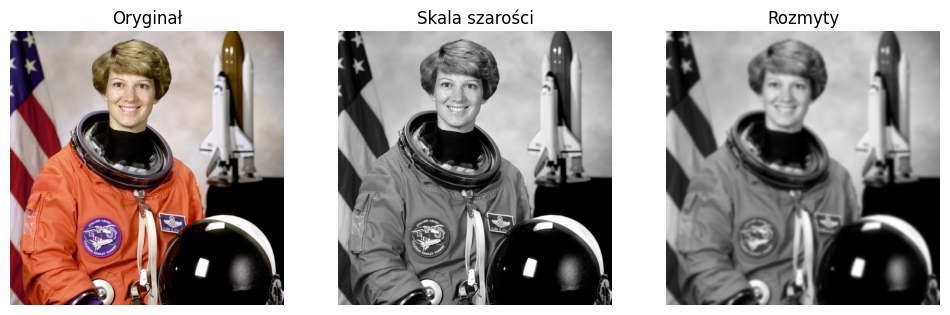

In [1]:
# ============================================
# Import potrzebnych bibliotek
# ============================================
import numpy as np                          # NumPy – obsługa tablic i obliczeń numerycznych
import matplotlib.pyplot as plt              # Matplotlib – do rysowania i wyświetlania obrazów
from skimage import io, color, exposure, filters, util, morphology, data
# skimage.io          – wczytywanie/zapisywanie obrazów
# skimage.color       – konwersja przestrzeni barw (np. RGB → grayscale)
# skimage.exposure    – regulacja jasności, kontrastu, histogramów itp.
# skimage.filters     – filtry obrazu (np. rozmycie, wykrywanie krawędzi)
# skimage.util        – operacje pomocnicze (np. dodawanie szumu)
# skimage.morphology  – operacje morfologiczne (np. erozja, dylatacja)
from skimage.metrics import structural_similarity as ssim
# skimage.metrics.ssim – metryka podobieństwa strukturalnego (ocena podobieństwa obrazów)

# ============================================
# Ustawienia wykresów
# ============================================
plt.rcParams["figure.figsize"] = (12, 4)     # Domyślny rozmiar rysunku: szerokość 12 cali, wysokość 4 cale

# ============================================
# Funkcja pomocnicza do wyświetlania obrazów w jednym wierszu
# ============================================
def show_row(images, titles=None, cmap=None):
    """
    Wyświetla kilka obrazów obok siebie w jednym wierszu.

    Parametry:
    -----------
    images : list
        Lista obrazów (tablic NumPy) do wyświetlenia.
    titles : list (opcjonalnie)
        Lista tytułów dla każdego obrazu.
    cmap : str (opcjonalnie)
        Mapa kolorów (np. 'gray' dla obrazów w skali szarości).
    """

    n = len(images)                          # Liczba obrazów
    fig, axes = plt.subplots(1, n)           # Tworzy jeden wiersz z n kolumnami (dla każdego obrazu jedna oś)

    # Iteracja po wszystkich obrazach i ich osiach
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(images[i], cmap=cmap)      # Wyświetla obraz (z opcjonalną mapą kolorów)
        ax.axis('off')                       # Ukrywa osie (ramki, skale, liczby)
        if titles:                           # Jeśli podano tytuły
            ax.set_title(titles[i])          # Ustawia tytuł nad obrazem

    plt.show()                               # Wyświetla całość

# ============================================
# Przykład użycia (opcjonalnie)
# ============================================
from skimage import data
img = data.astronaut()                     # Wczytanie przykładowego obrazu
gray = color.rgb2gray(img)                 # Konwersja na skalę szarości
blur = filters.gaussian(gray, sigma=2)     # Rozmycie obrazu filtrem Gaussa
# Wyświetlenie trzech obrazów obok siebie
show_row([img, gray, blur],
          titles=["Oryginał", "Skala szarości", "Rozmyty"],
          cmap='gray')


# Wczytanie + kanały + histogram

Co robi ten kod:
* Wczytuje obraz z pliku (np. lena.png).

* Zapewnia, że ma format RGB (3 kanały).

* Rozdziela obraz na kanały R, G, B.

* Wyświetla oryginał i każdy kanał osobno.

* Konwertuje obraz do skali szarości.

* Rysuje histogram jasności – pokazujący rozkład tonalny obrazu.

RGB


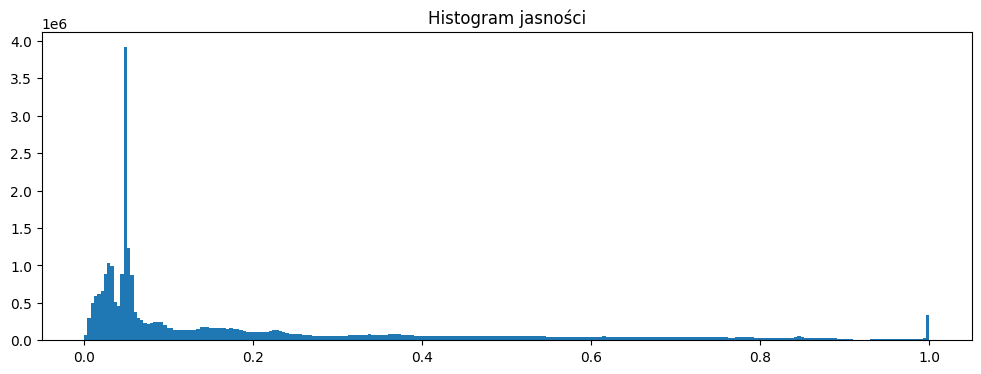

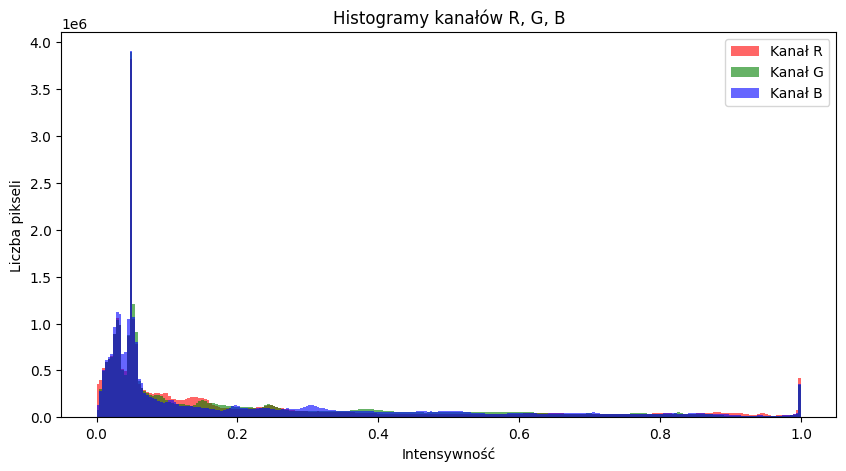

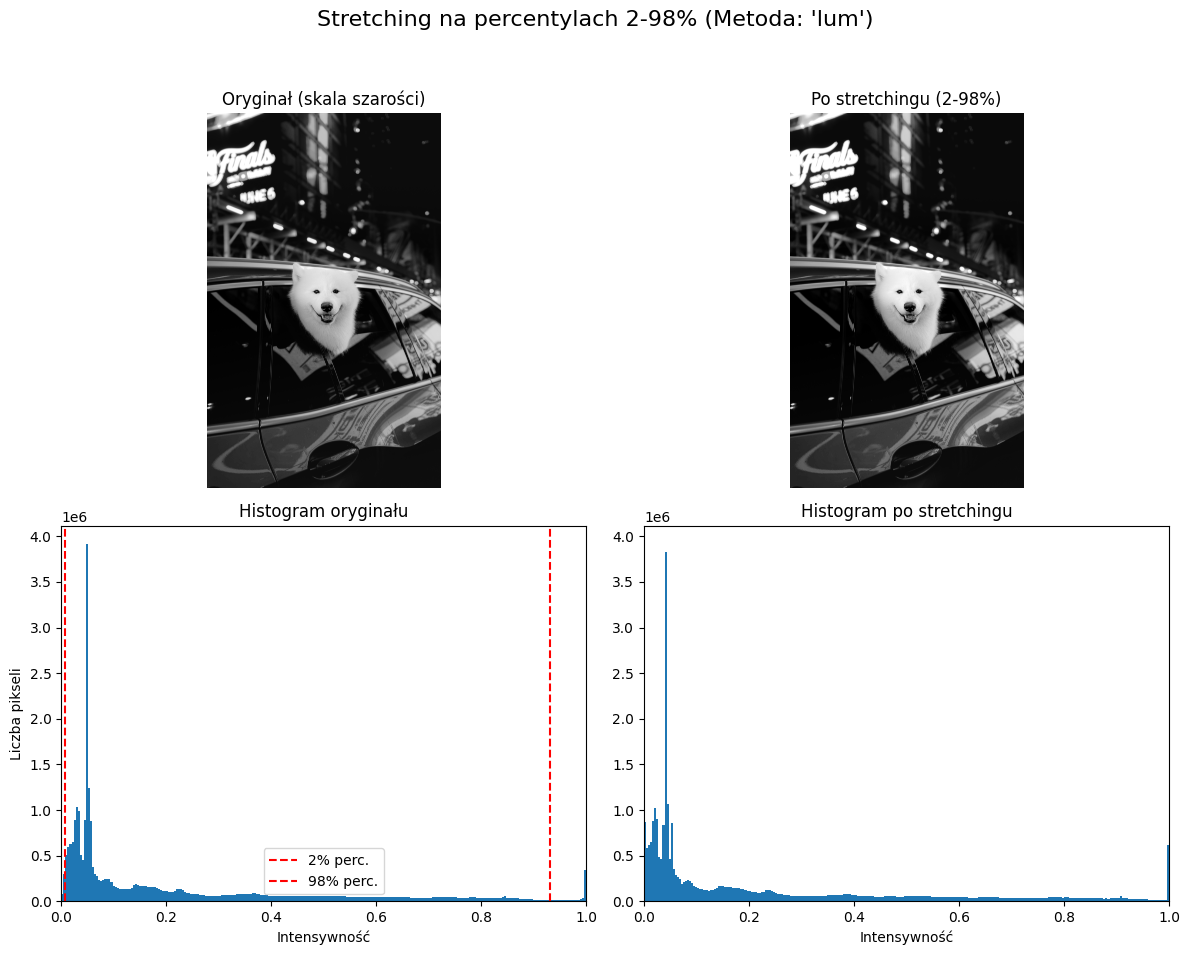

In [28]:
# ============================================
# Wczytanie obrazu i analiza kanałów kolorów
# ============================================
from skimage.util import img_as_float
# TODO: Podmień ścieżkę na swój plik lub URL (skimage.io potrafi też czytać obrazy z internetu)
#img = io.imread('lena.png')  # Wczytuje obraz z pliku; może być RGB, RGBA lub grayscale (2D)
from PIL import Image
img = Image.open("fluffy-dog.jpg")
print(img.mode)  #--> RGB
img = io.imread("fluffy-dog.jpg")
# ============================================
# Ujednolicenie formatu obrazu do RGB
# ============================================
# Jeśli obraz jest w skali szarości (2D) → powiel kanał 3 razy, aby uzyskać pseudo-RGB.
# Jeśli obraz ma kanał alfa (RGBA) → usuń go, zostawiając tylko pierwsze 3 kanały (R, G, B).
if img.ndim == 2:
    img_rgb = np.stack([img, img, img], axis=-1)  # Tworzy RGB z jednego kanału
else:
    img_rgb = img[..., :3]  # Usuwa kanał alfa (jeśli istnieje), zachowując R, G, B

# ============================================
# a) Podgląd RGB i kanałów R / G / B
# ============================================
# Wyodrębnienie poszczególnych kanałów koloru z obrazu RGB.
r = img_rgb[..., 0]  # Kanał czerwony (Red)
g = img_rgb[..., 1]  # Kanał zielony (Green)
b = img_rgb[..., 2]  # Kanał niebieski (Blue)

# Wyświetlenie oryginalnego obrazu RGB oraz trzech kanałów R, G, B obok siebie.
# Kanały są pokazane w skali szarości, aby uwidocznić ich intensywność.
# show_row([img_rgb, r, g, b],
#           ['RGB', 'R', 'G', 'B'],
#           cmap=['', 'gray', 'gray', 'gray'])

# ============================================
# b) Histogram jasności obrazu
# ============================================
# Konwersja z RGB do skali szarości – wykorzystuje wagowe przeliczenie ludzkiej percepcji jasności:
# Y = 0.2125 * R + 0.7154 * G + 0.0721 * B
# Wynik to obraz typu float z wartościami od 0 (czarny) do 1 (biały).
gray = color.rgb2gray(img_rgb)

# Rysowanie histogramu rozkładu jasności pikseli.
# gray.ravel() spłaszcza obraz 2D do jednowymiarowej tablicy wszystkich wartości pikseli.
plt.figure()
plt.hist(gray.ravel(), bins=256, range=(0, 1))  # 256 przedziałów dla jasności od 0 do 1
plt.title('Histogram jasności')  # Tytuł wykresu
plt.show()  # Wyświetlenie histogramu


def get_grayscale(image_rgb_float, method='lum'):
    if method == 'lum':
        return color.rgb2gray(image_rgb_float)
    elif method == 'avg':
        return np.mean(image_rgb_float, axis=2)
    elif method == 'r':
        return image_rgb_float[..., 0]
    elif method == 'g':
        return image_rgb_float[..., 1]
    elif method == 'b':
        return image_rgb_float[..., 2]
    else:
        raise ValueError(f"Nieznana metoda konwersji: {method}")
def perform_histogram_exploration(image_rgb_float, p_low=2, p_high=98, gray_method='lum'):
    """Główna funkcja rysująca mozaikę 2x2 (przed/po) dla stretchingu."""

    gray = get_grayscale(image_rgb_float, method=gray_method)

    val_low, val_high = np.percentile(gray, (p_low, p_high))

    gray_stretched = exposure.rescale_intensity(gray, in_range=(val_low, val_high))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    ax = axes.ravel()

    fig.suptitle(f"Stretching na percentylach {p_low}-{p_high}% (Metoda: '{gray_method}')", fontsize=16)

    # Obraz oryginalny
    ax[0].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[0].set_title("Oryginał (skala szarości)")
    ax[0].axis('off')

    # Obraz po stretchingu
    ax[1].imshow(gray_stretched, cmap='gray', vmin=0, vmax=1)
    ax[1].set_title(f"Po stretchingu ({p_low}-{p_high}%)")
    ax[1].axis('off')

    # Histogram oryginału
    hist_bins = 256
    hist_range = (0.0, 1.0)

    ax[2].hist(gray.ravel(), bins=hist_bins, range=hist_range)
    ax[2].set_title("Histogram oryginału")
    ax[2].set_xlabel("Intensywność")
    ax[2].set_ylabel("Liczba pikseli")
    ax[2].set_xlim(hist_range)
    ax[2].axvline(val_low, color='red', linestyle='--', label=f'{p_low}% perc.')
    ax[2].axvline(val_high, color='red', linestyle='--', label=f'{p_high}% perc.')
    ax[2].legend()

    # Histogram po stretchingu
    ax[3].hist(gray_stretched.ravel(), bins=hist_bins, range=hist_range)
    ax[3].set_title("Histogram po stretchingu")
    ax[3].set_xlabel("Intensywność")
    ax[3].set_xlim(hist_range)
    ax[3].sharey(ax[2])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

img_uint8 = img

# 2. Ujednolicenie formatu do RGB (float)
if img_uint8.ndim == 2:
    img_rgb_uint8 = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)
else:
    img_rgb_uint8 = img_uint8[..., :3]

img_rgb_float = img_as_float(img_rgb_uint8)

# 3. Rysowanie histogramów R, G, B (Punkt 2 zadania)
r = img_rgb_float[..., 0]
g = img_rgb_float[..., 1]
b = img_rgb_float[..., 2]

plt.figure(figsize=(10, 5))
plt.hist(r.ravel(), bins=256, range=(0, 1), color='red', alpha=0.6, label='Kanał R')
plt.hist(g.ravel(), bins=256, range=(0, 1), color='green', alpha=0.6, label='Kanał G')
plt.hist(b.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.6, label='Kanał B')
plt.title('Histogramy kanałów R, G, B')
plt.xlabel("Intensywność")
plt.ylabel("Liczba pikseli")
plt.legend()
plt.show()

# 4. Wywołanie głównej funkcji (Punkt 3, 4, 5 zadania)
perform_histogram_exploration(img_rgb_float, p_low=2, p_high=98, gray_method='lum')


Normalizacja, Wyrównanie histogramu





# Normalizacja histogramu (ang. histogram normalization lub contrast stretching)
Normalizacja rozciąga zakres jasności obrazu tak, by wykorzystać cały możliwy przedział — np. od 0 do 1 (dla float) lub od 0 do 255 (dla uint8).

Przykład:

Jeśli obraz ma piksele tylko w zakresie [50, 180], to normalizacja przeskaluje je do [0, 255].
Dzięki temu:
* cienie staną się czarne,
* jasne miejsca – jaśniejsze,
* kontrast wzrośnie liniowo.

# Wyrównanie histogramu (ang. histogram equalization)
Wyrównanie histogramu zmienia rozkład jasności pikseli, aby histogram był bardziej płaski i równomierny.
Nie tylko rozciąga, ale też nieliniowo przekształca wartości, tak by różne poziomy jasności były reprezentowane z podobną częstością.

Efekt:
* zwiększa kontrast lokalny,
* uwidacznia szczegóły w ciemnych i jasnych partiach obrazu,
* histogram po operacji staje się „bardziej równy”.

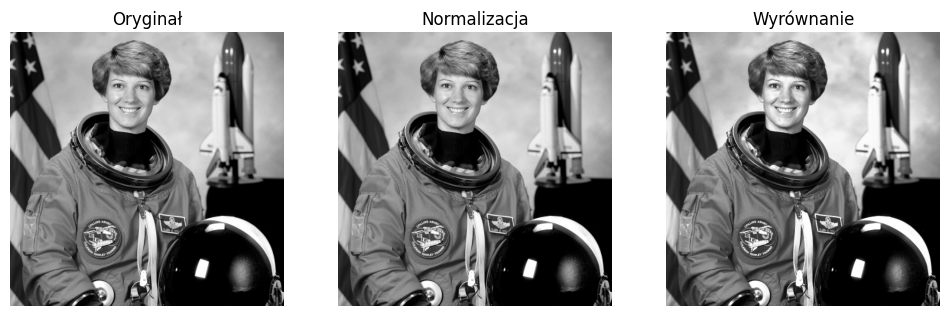

In [3]:
# Import potrzebnych bibliotek
from skimage import data, color, exposure
import matplotlib.pyplot as plt

# Wczytanie obrazu astronauty z wbudowanego zestawu skimage i konwersja do skali szarości
# Funkcja rgb2gray() zamienia obraz RGB na odcienie szarości, co ułatwia analizę jasności.
img = color.rgb2gray(data.astronaut())

# Normalizacja kontrastu
# Funkcja rescale_intensity() rozciąga zakres jasności pikseli tak, by najmniejsza wartość = 0, a największa = 1.
# Dzięki temu obraz lepiej wykorzystuje dostępny zakres intensywności i ma wyraźniejszy kontrast.
norm = exposure.rescale_intensity(img, in_range='image', out_range=(0, 1))

# Wyrównanie histogramu (Histogram Equalization)
# equalize_hist() modyfikuje rozkład intensywności tak, aby histogram był bardziej równomierny.
# To poprawia kontrast, szczególnie w ciemnych i jasnych fragmentach obrazu.
eq = exposure.equalize_hist(img)

# Wizualizacja wyników obok siebie
# Tworzymy 3 wykresy: oryginał, wersję po normalizacji i po wyrównaniu histogramu.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ['Oryginał', 'Normalizacja', 'Wyrównanie']

# Wyświetlenie każdego obrazu w skali szarości z odpowiednim tytułem
for ax, im, t in zip(axes, [img, norm, eq], titles):
    ax.imshow(im, cmap='gray')  # Wyświetlenie obrazu w odcieniach szarości
    ax.set_title(t)             # Ustawienie tytułu wykresu
    ax.axis('off')              # Ukrycie osi dla czystszego wyglądu

# Wyświetlenie całej figury
plt.show()

# Podstawowe przekształcenia geometryczne obrazu
Przekształcenia geometryczne należą do podstawowych operacji w przetwarzaniu obrazów cyfrowych. Ich celem jest zmiana położenia, orientacji lub rozmiaru elementów obrazu bez modyfikacji jego treści (czyli wartości jasności i kolorów). W przeciwieństwie do metod poprawy kontrastu czy filtracji, przekształcenia geometryczne nie zmieniają informacji o pikselach, lecz zmieniają ich rozmieszczenie w przestrzeni obrazu.

Do najczęściej stosowanych przekształceń geometrycznych należą:

* Translacja (przesunięcie) – zmiana położenia obrazu w płaszczyźnie (np.
przesunięcie w prawo lub w dół).
* Rotacja (obrót) – obrót obrazu wokół zadanego punktu, najczęściej środka.
* Skalowanie (reskalowanie) – powiększenie lub pomniejszenie obrazu poprzez zmianę odległości między pikselami.
* Odbicie (symetria lustrzana) – zamiana stron obrazu w poziomie lub pionie.
* Transformacje afiniczne (affine transformations) – ogólniejsze przekształcenia, które obejmują rotację, skalowanie, translację i ścinanie (shear).
* Transformacje perspektywiczne (projective transformations) – bardziej złożone operacje pozwalające odwzorować efekty wynikające ze zmiany punktu widzenia kamery.

Poniżej w kodzie zastosowano przykład przekaszłcenia obrazu:
* Obrót (rotate) – zmienia orientację obrazu o określony kąt.
* Odbicie lustrzane (flip) – odwraca obraz w poziomie.
* Skalowanie (rescale) – zmniejsza lub powiększa obraz.

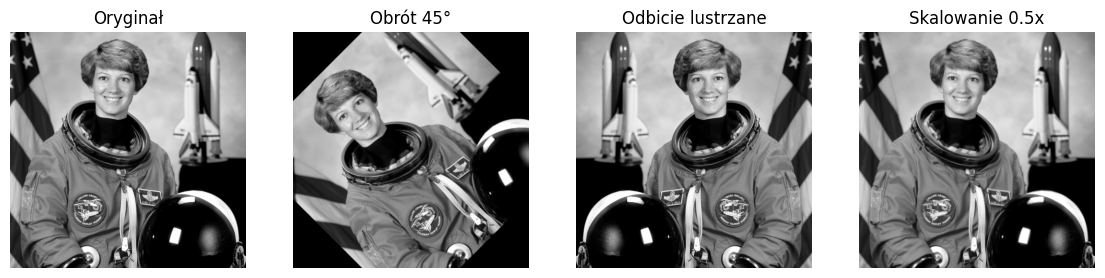

In [4]:
# Import potrzebnych bibliotek
from skimage import data, color, transform
import matplotlib.pyplot as plt

# Wczytanie przykładowego obrazu i konwersja do skali szarości
# Używamy zdjęcia astronauty, które jest dostępne w skimage.
img = color.rgb2gray(data.astronaut())

# Obrót obrazu o 45 stopni
# transform.rotate() obraca obraz o zadany kąt (w stopniach, przeciwnie do ruchu wskazówek zegara).
rotated = transform.rotate(img, angle=45)

# Odbicie lustrzane w poziomie
# slicing [:, ::-1] odwraca kolejność kolumn (pionowych pikseli), co daje efekt lustrzanego odbicia.
flipped = img[:, ::-1]

# Skalowanie (zmiana rozmiaru)
# transform.rescale() zmienia wielkość obrazu o podany współczynnik (tu 0.5 = zmniejszenie do 50%).
scaled = transform.rescale(img, scale=0.5, anti_aliasing=True)

# Wizualizacja wszystkich przekształceń
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Oryginał', 'Obrót 45°', 'Odbicie lustrzane', 'Skalowanie 0.5x']

# Wyświetlenie każdego obrazu w odcieniach szarości
for ax, im, t in zip(axes, [img, rotated, flipped, scaled], titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

# Wyświetlenie wyniku
plt.show()

# Konwersja przestrzeni barw

Przestrzeń barw (ang. color space) to sposób matematycznego opisu koloru, który określa, jak kolory są reprezentowane i interpretowane przez komputer.

Różne przestrzenie barw lepiej nadają się do różnych zastosowań w przetwarzaniu obrazów i wizji komputerowej.
Konwersja umożliwia:

* Oddzielenie jasności od koloru
W przestrzeniach takich jak HSV, LAB czy YUV, można analizować jasność (np. „Value”, „L” lub „Y”) osobno od barwy.
To bardzo przydatne przy analizie obrazów, gdy oświetlenie jest nierównomierne.
* Segmentację kolorów
W przestrzeni HSV łatwo odseparować obiekty o określonej barwie, bo „Hue” opisuje odcień w sposób intuicyjny (np. czerwony ≈ 0°, niebieski ≈ 240°).
* Lepsze odwzorowanie percepcji człowieka
W przestrzeni LAB różnice między kolorami są bardziej zgodne z tym, jak widzi je człowiek — przydatne przy porównywaniu obrazów czy ocenie jakości.
* Kompresję i przetwarzanie wideo
Przestrzeń YUV (lub YCbCr) pozwala oddzielić luminancję (jasność) od chrominancji (koloru).
Dzięki temu można kompresować dane o barwie bez dużej utraty jakości obrazu — tak działa np. JPEG i MPEG.

Dodatkowe funkcje w skimage.color:

* color.rgb2gray() – RGB → skala szarości
* color.gray2rgb() – grayscale → RGB
* color.hsv2rgb() – HSV → RGB
* color.lab2rgb() – LAB → RGB
* color.yuv2rgb() – YUV → RGB


Analiza kodu poniżej:
* Wczytujemy obraz RGB (np. astronauta ze skimage.data).
* Konwertujemy go kolejno do innych przestrzeni barw:
* rgb2hsv() – użyteczne np. przy segmentacji kolorów.
* rgb2lab() – przestrzeń dopasowana do ludzkiej percepcji kolorów.
* rgb2yuv() – często stosowana w kompresji wideo i obrazów.

Wizualizujemy oryginał i poszczególne kanały każdej przestrzeni:

* w HSV: H (odcień), S (nasycenie), V (jasność),
* w LAB: L (luminancja), a i b (składowe kolorów),
* w YUV: Y (jasność), U i V (informacja o barwie).




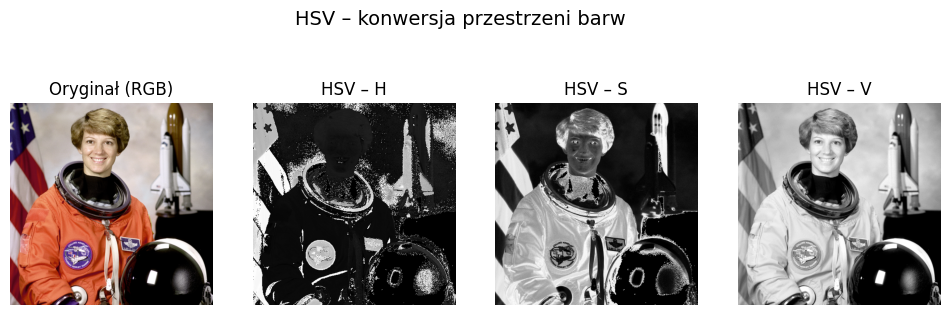

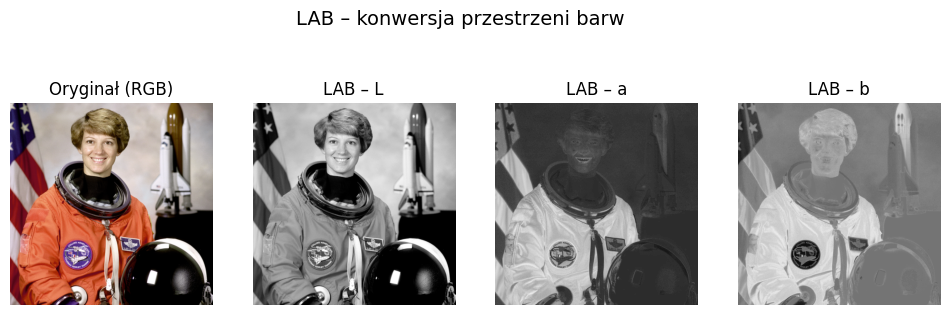

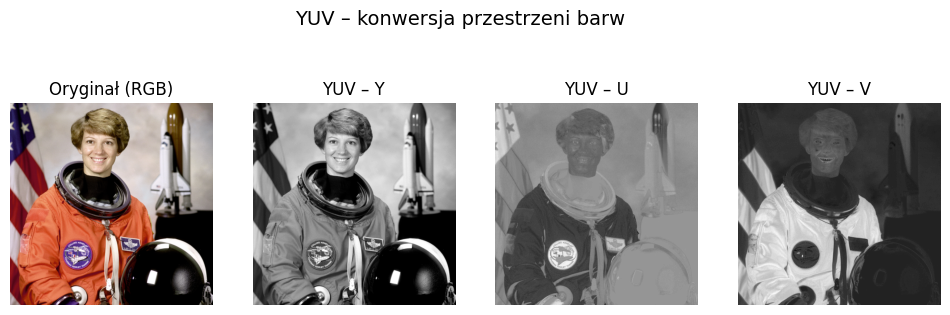

In [5]:
# ============================================
# Przykład: Zmiana przestrzeni barw w Pythonie (scikit-image)
# ============================================

import matplotlib.pyplot as plt
from skimage import data, color

# Wczytanie przykładowego obrazu z biblioteki skimage
img_rgb = data.astronaut()   # Obraz w formacie RGB (Red, Green, Blue)

# ============================================
# RGB → HSV
# ============================================
# HSV (Hue, Saturation, Value)
# Hue – barwa (0–1)
# Saturation – nasycenie koloru (0–1)
# Value – jasność (0–1)
img_hsv = color.rgb2hsv(img_rgb)

# ============================================
# RGB → LAB
# ============================================
# LAB to przestrzeń, w której:
# L – jasność (Lightness)
# a – składowa koloru od zielonego do czerwonego
# b – składowa koloru od niebieskiego do żółtego
img_lab = color.rgb2lab(img_rgb)

# ============================================
# RGB → YUV
# ============================================
# YUV (lub YCbCr) rozdziela luminancję (Y) od chrominancji (U,V).
# Często używana w telewizji i kompresji wideo (np. w JPEG).
img_yuv = color.rgb2yuv(img_rgb)

# ============================================
# Wizualizacja wyników
# ============================================
# Tworzymy 3 wiersze (dla przestrzeni HSV, LAB, YUV)
# i w każdym pokazujemy oryginał oraz 3 kanały składowe
def show_color_space_conversion(original, converted, space_name, channel_names):
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    fig.suptitle(f'{space_name} – konwersja przestrzeni barw', fontsize=14)
    axes[0].imshow(original)
    axes[0].set_title("Oryginał (RGB)")
    axes[0].axis("off")

    for i, name in enumerate(channel_names):
        axes[i + 1].imshow(converted[..., i], cmap='gray')
        axes[i + 1].set_title(f'{space_name} – {name}')
        axes[i + 1].axis('off')
    plt.show()

# Wyświetlenie dla różnych przestrzeni
show_color_space_conversion(img_rgb, img_hsv, "HSV", ["H", "S", "V"])
show_color_space_conversion(img_rgb, img_lab, "LAB", ["L", "a", "b"])
show_color_space_conversion(img_rgb, img_yuv, "YUV", ["Y", "U", "V"])

# Zadanie 2

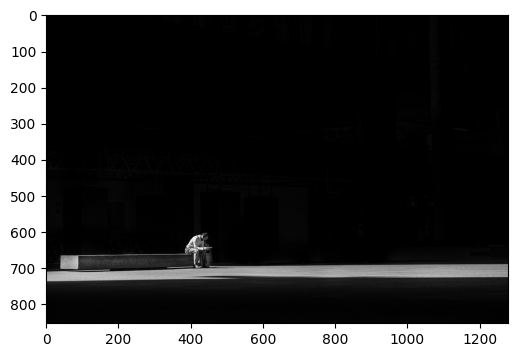

In [22]:
# from skimage import io, color
# from PIL import Image
# img2 = Image.open("ex2.jpg")
# print(img2.mode)  #--> RGB
img2 = io.imread('ex2.jpg')
img2 = color.rgb2gray(img2)
plt.imshow(img2, 'gray')


In [7]:
from skimage.util import img_as_float, img_as_ubyte

def analyze_image_versions(image):
    #converting an image to floating point format, with values in [0, 1] from [0-255]
    image_float = img_as_float(image)
    #given by the definition
    perc_low, perc_high = 2, 98
    gamma_val = 0.6

    params = {
        'normalizacja': f'percentyle {perc_low}-{perc_high}',
        'gamma': gamma_val
    }

    p_low, p_high = np.percentile(image_float, (perc_low, perc_high))
    img_norm = exposure.rescale_intensity(image_float, in_range=(p_low, p_high))

    img_for_eq = img_as_ubyte(image_float)
    img_eq = exposure.equalize_hist(img_for_eq)


    img_gamma = exposure.adjust_gamma(image_float, gamma=gamma_val)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
    ax = axes.ravel()

    ax[0].imshow(image, cmap='gray')
    ax[0].set_title("Oryginał")

    ax[1].imshow(img_norm, cmap='gray')
    ax[1].set_title(f"Normalizacja (percentyle {perc_low}-{perc_high})")

    ax[2].imshow(img_eq, cmap='gray')
    ax[2].set_title("Wyrównanie histogramu")

    ax[3].imshow(img_gamma, cmap='gray')
    ax[3].set_title(rf"Korekcja gamma ($\gamma$={gamma_val})")

    for a in ax:
        a.axis('off')

    plt.tight_layout()

    return fig, params

In [8]:
def plot_histograms(image, params):
    image_float = img_as_float(image) #going for 0 - 1 for precision
    gamma_val = params['gamma']
    p_str = params['normalizacja'].split(' ')[1].split('-')
    perc_low, perc_high = int(p_str[0]), int(p_str[1])

    p_low, p_high = np.percentile(image_float, (perc_low, perc_high))
    # image after stretching or shrinking its intensity levels by percentiles
    img_norm = exposure.rescale_intensity(image_float, in_range=(p_low, p_high))

    #back to 0 - 255 for compatiblity
    img_for_eq = img_as_ubyte(image_float)
    img_eq = exposure.equalize_hist(img_for_eq) #his

    img_gamma = exposure.adjust_gamma(image_float, gamma=gamma_val) #after gamma correction
    # 2 x 2, 12 by 8 inches
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    ax = axes.ravel() #from 2 x 2 to vector of len 4

    bins = 256

    def plot_hist_ax(ax_obj, img_data, title):
        if img_data.dtype == np.uint8:
            lims = (0, 255)
        else:
            lims = (0.0, 1.0)

        ax_obj.hist(img_data.ravel(), bins=bins, range=lims, histtype='step', color='black')
        ax_obj.set_title(title)
        ax_obj.set_xlim(lims)
        ax_obj.set_yticks([])
    plot_hist_ax(ax[0], image, "Oryginał (histogram)")
    plot_hist_ax(ax[1], img_norm, "Normalizacja (histogram)")
    plot_hist_ax(ax[2], img_eq, "Wyrównanie (histogram)")
    plot_hist_ax(ax[3], img_gamma, rf"Gamma $\gamma$={gamma_val} (histogram)")

    fig.suptitle("Porównanie histogramów (zgodnie ze Wskazówkami)", fontsize=16)
    plt.tight_layout()

    return fig

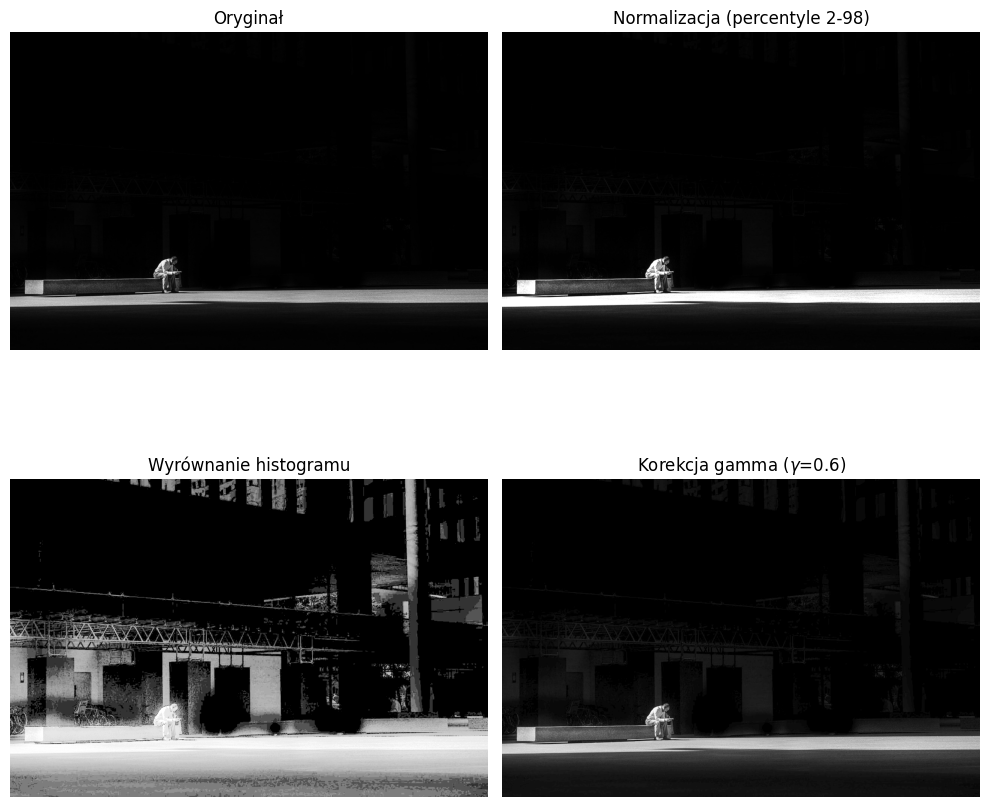

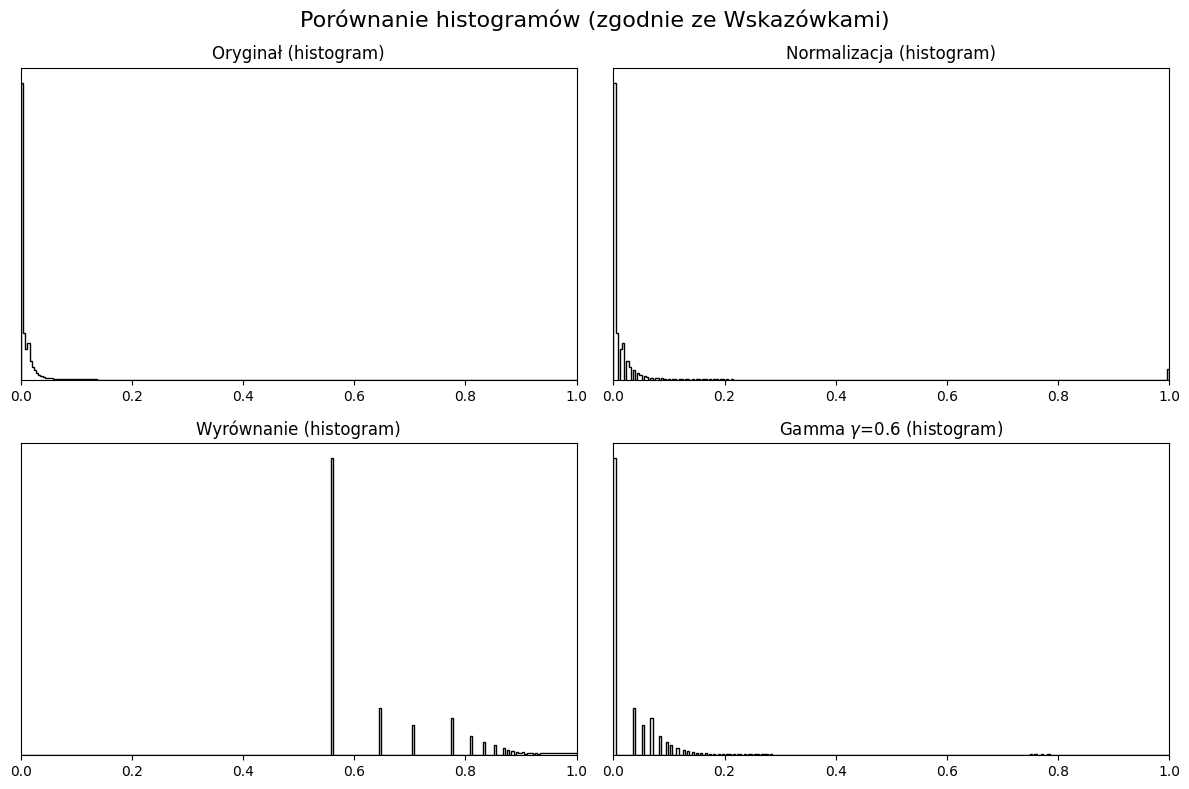

In [15]:
if img2.ndim == 3:
    img2 = color.rgb2gray(img2)

fig_images, params = analyze_image_versions(img2)

fig_histograms = plot_histograms(img2, params)

plt.show()

# Zadanie 3

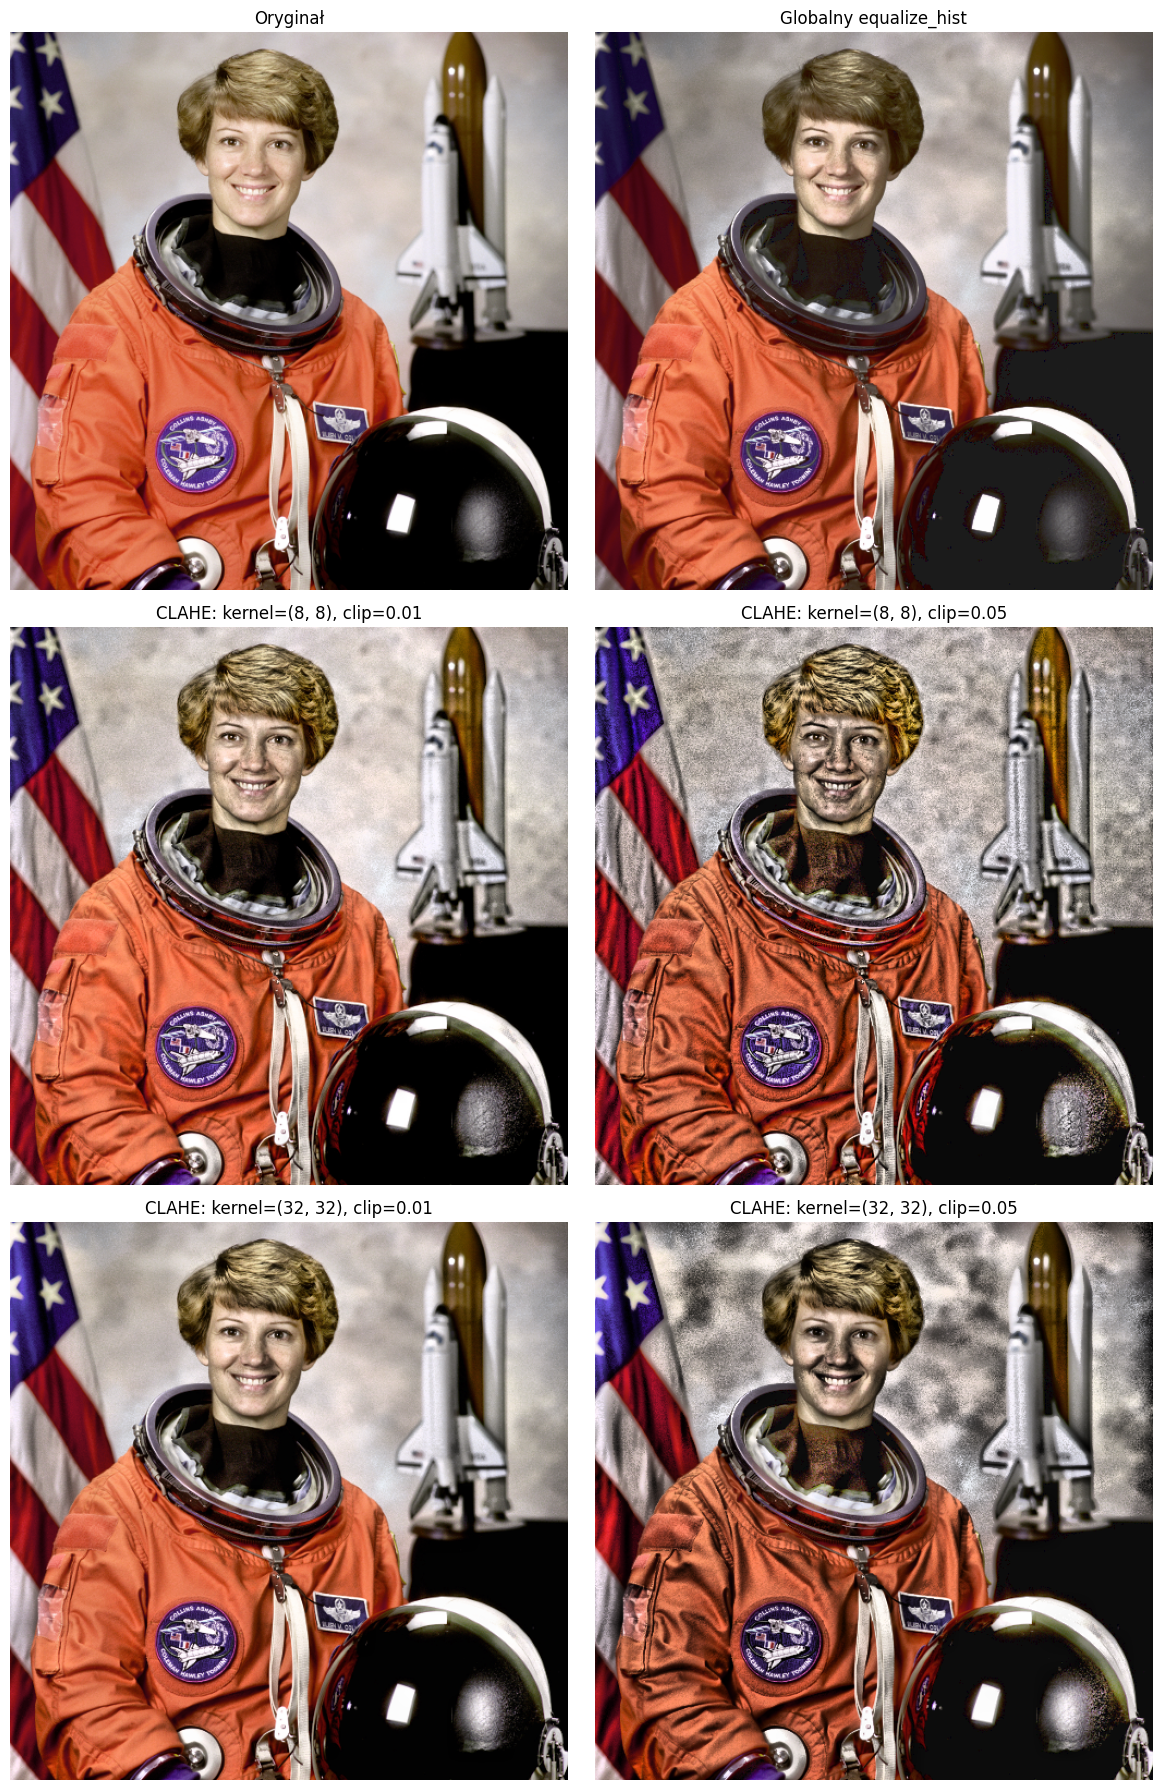

--- Komentarz (Wynik) ---
Globalne wyrównanie histogramu (`equalize_hist`) silnie podbija kontrast, ale prowadzi do 'przepalenia' (clippingu) jasnych obszarów, jak widać na kasku astronauty, gdzie tracone są detale. CLAHE (`equalize_adapthist`) znacznie lepiej radzi sobie z ochroną świateł. 
Wpływ parametrów: 
1. **Rozmiar płytki (kernel_size):** Określa lokalność adaptacji. Małe płytki (np. 8x8) wzmacniają very drobne detale i tekstury, ale mogą drastycznie podbić szum w ciemnych obszarach (np. w tle za astronautą). Duże płytki (np. 32x32) działają bardziej globalnie, dając łagodniejszy efekt. 
2. **Limit przycięcia (clip_limit):** Kontroluje siłę wzmocnienia. Niski limit (0.01) daje subtelny, naturalny efekt i najlepszą ochronę świateł. Wysoki limit (0.05) mocno podbija lokalny kontrast, co może prowadzić do artefaktów, 'plastikowego' wyglądu oraz powstawania 'halo' wokół krawędzi.


In [23]:
def clahe_demo(img, clip_limit=0.01, kernel_size=None):
    img_f = img_as_float(img)

    if img_f.ndim == 3:
        hsv_img = color.rgb2hsv(img_f)
        v_channel = hsv_img[:, :, 2]

        v_clahe = exposure.equalize_adapthist(
            v_channel,
            kernel_size=kernel_size,
            clip_limit=clip_limit
        )

        hsv_img_clahe = hsv_img.copy()
        hsv_img_clahe[:, :, 2] = v_clahe

        img_out = color.hsv2rgb(hsv_img_clahe)

    else:
        img_out = exposure.equalize_adapthist(
            img_f,
            kernel_size=kernel_size,
            clip_limit=clip_limit
        )

    return img_out

def global_equalize_hist_rgb(img):
    img_f = img_as_float(img)
    if img_f.ndim == 3:
        hsv_img = color.rgb2hsv(img_f)
        v_channel = hsv_img[:, :, 2]

        v_eq = exposure.equalize_hist(v_channel)

        hsv_img_eq = hsv_img.copy()
        hsv_img_eq[:, :, 2] = v_eq

        img_out = color.hsv2rgb(hsv_img_eq)
    else:
        img_out = exposure.equalize_hist(img_f)
    return img_out


image = data.astronaut()

params = [
    {'kernel_size': (8, 8), 'clip_limit': 0.01},
    {'kernel_size': (8, 8), 'clip_limit': 0.05},
    {'kernel_size': (32, 32), 'clip_limit': 0.01},
    {'kernel_size': (32, 32), 'clip_limit': 0.05},
]

img_global_eq = global_equalize_hist_rgb(image)

img_clahe_variants = [
    clahe_demo(image, p['clip_limit'], p['kernel_size']) for p in params
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 18))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title("Oryginał")

ax[1].imshow(img_global_eq)
ax[1].set_title("Globalny equalize_hist")

for i, img_clahe in enumerate(img_clahe_variants):
    p = params[i]
    title = f"CLAHE: kernel={p['kernel_size']}, clip={p['clip_limit']}"
    ax[i+2].imshow(img_clahe)
    ax[i+2].set_title(title)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

print("--- Komentarz (Wynik) ---")
print(
    "Globalne wyrównanie histogramu (`equalize_hist`) silnie podbija kontrast, "
    "ale prowadzi do 'przepalenia' (clippingu) jasnych obszarów, jak widać na "
    "kasku astronauty, gdzie tracone są detale. "
    "CLAHE (`equalize_adapthist`) znacznie lepiej radzi sobie z ochroną świateł. \n"
    "Wpływ parametrów: \n"
    "1. **Rozmiar płytki (kernel_size):** Określa lokalność adaptacji. Małe płytki "
    "(np. 8x8) wzmacniają very drobne detale i tekstury, ale mogą drastycznie "
    "podbić szum w ciemnych obszarach (np. w tle za astronautą). "
    "Duże płytki (np. 32x32) działają bardziej globalnie, dając łagodniejszy efekt. \n"
    "2. **Limit przycięcia (clip_limit):** Kontroluje siłę wzmocnienia. Niski limit "
    "(0.01) daje subtelny, naturalny efekt i najlepszą ochronę świateł. "
    "Wysoki limit (0.05) mocno podbija lokalny kontrast, co może prowadzić do "
    "artefaktów, 'plastikowego' wyglądu oraz powstawania 'halo' wokół krawędzi."
)

# Zadaniae 4

Generowanie planszy 3x3...


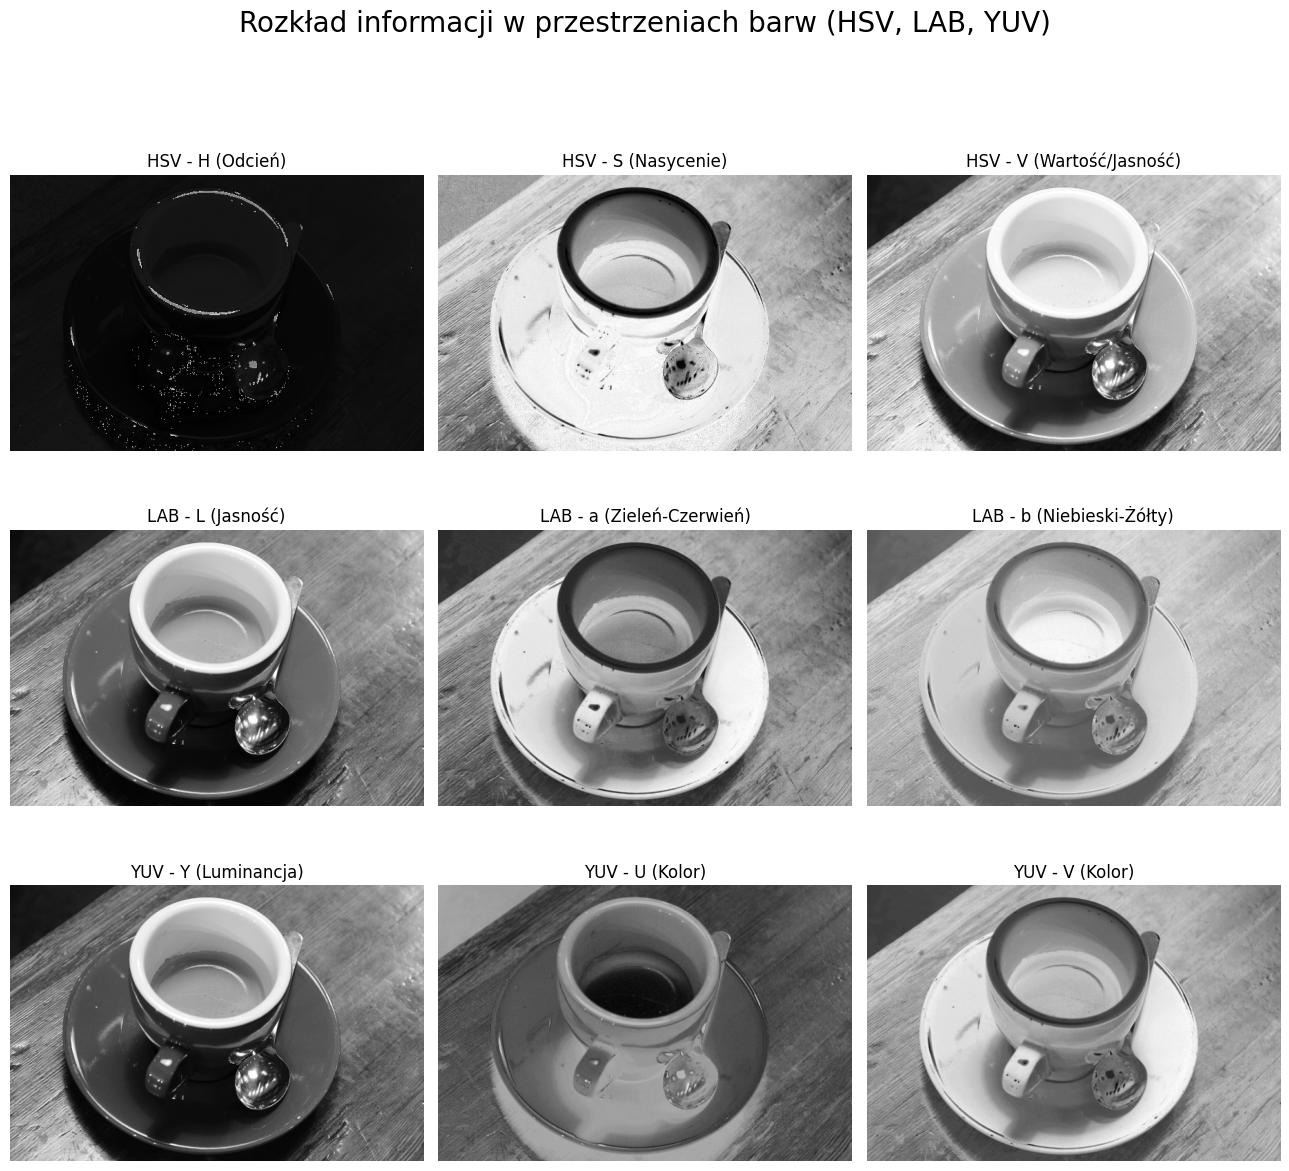

In [24]:
image_rgb_uint8 = data.coffee()
image_rgb = img_as_float(image_rgb_uint8)

image_hsv = color.rgb2hsv(image_rgb)
image_lab = color.rgb2lab(image_rgb)
image_yuv = color.rgb2yuv(image_rgb)

channels = {
    'HSV - H (Odcień)': image_hsv[:, :, 0],
    'HSV - S (Nasycenie)': image_hsv[:, :, 1],
    'HSV - V (Wartość/Jasność)': image_hsv[:, :, 2],

    'LAB - L (Jasność)': image_lab[:, :, 0],
    'LAB - a (Zieleń-Czerwień)': image_lab[:, :, 1],
    'LAB - b (Niebieski-Żółty)': image_lab[:, :, 2],

    'YUV - Y (Luminancja)': image_yuv[:, :, 0],
    'YUV - U (Kolor)': image_yuv[:, :, 1],
    'YUV - V (Kolor)': image_yuv[:, :, 2],
}

print("Generowanie planszy 3x3...")

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
ax = axes.ravel()

for i, (title, channel) in enumerate(channels.items()):
    im = ax[i].imshow(channel, cmap='gray')

    ax[i].set_title(title, fontsize=12)
    ax[i].axis('off') # Wyłączamy osie dla czytelności

fig.suptitle("Rozkład informacji w przestrzeniach barw (HSV, LAB, YUV)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Dopasuj układ, robiąc miejsce na główny tytuł
plt.show()

Patrząc na te 9 obrazków, od razu widać, że można je podzielić na dwie grupy.
Kanały "czarno-białe" (od jasności)
To kanały L, Y oraz V. To na nich najlepiej widać kształty, krawędzie i fakturę (np. słoje drewna czy materiał ubrania). Wyglądają po prostu jak zwykły obraz czarno-biały.

Z tej trójki L (z LAB) jest najlepszy, bo pokazuje jasność dokładnie tak, jak widzi ją ludzkie oko.

Y (z YUV) jest bardzo podobny i też świetnie sobie radzi (to ten kanał używany w starych telewizorach do przesyłania obrazu czarno-białego).

V (z HSV) jest najprostszy, ale czasem trochę "oszukuje", bo miesza informacje o jasności z informacją o kolorze.

Kanały "od koloru" 🎨
To cała reszta: H, S, a, b, U oraz V. One przechowują tylko informację o barwie (np. czy coś jest czerwone, czy niebieskie) i nasyceniu (jak bardzo "żywy" i intensywny jest kolor).

Na tych obrazkach prawie nie widać krawędzi ani kształtów, chyba że dwa obiekty miały tę samą jasność, ale zupełnie inny kolor. Kanały a, b, U i V przechowują kolor w dziwny sposób, np. na osi "ile jest zielonego vs. ile czerwonego". Dlatego miejsca, które w oryginale nie miały koloru (były szare lub białe), na tych obrazkach też są po prostu "nijakie" (mają średnią szarość).